In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SparkML_Titanic") \
    .getOrCreate()

25/12/26 16:59:47 WARN Utils: Your hostname, spark resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
25/12/26 16:59:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/26 16:59:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/26 16:59:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
df = spark.read.csv("../data/titanic.csv", header=True, inferSchema=True)
df.show(5)
df.printSchema()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
+-----------+--------+------+--------------------+------+----+-----+-----+------

In [3]:
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler

In [4]:
df_ml = df.select(
    "Survived",
    "Pclass",
    "Age",
    "Fare"
).dropna()

In [5]:
assembler = VectorAssembler(
    inputCols=["Pclass", "Age", "Fare"],
    outputCol="features"
)

data = assembler.transform(df_ml)
data = data.select(
    col("Survived").alias("label"),
    "features"
)

In [6]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

In [7]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression()
lr_model = lr.fit(train_data)

In [8]:
pred_lr = lr_model.transform(test_data)
pred_lr.select("label", "prediction").show(10)

+-----+----------+
|label|prediction|
+-----+----------+
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
|    0|       1.0|
+-----+----------+
only showing top 10 rows



In [9]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy_lr = evaluator.evaluate(pred_lr)
accuracy_lr

0.6578947368421053

In [10]:
pred_lr.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   27|
|    0|       0.0|   48|
|    1|       1.0|   27|
|    0|       1.0|   12|
+-----+----------+-----+



In [11]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt_model = dt.fit(train_data)

In [12]:
pred_dt = dt_model.transform(test_data)
accuracy_dt = evaluator.evaluate(pred_dt)
accuracy_dt

0.5964912280701754

In [13]:
pred_dt.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   38|
|    0|       0.0|   52|
|    1|       1.0|   16|
|    0|       1.0|    8|
+-----+----------+-----+



In [14]:
from pyspark.sql import Row

spark.createDataFrame([
    Row(Model="Logistic Regression", Accuracy=float(accuracy_lr)),
    Row(Model="Decision Tree", Accuracy=float(accuracy_dt))
]).show()

+-------------------+------------------+
|              Model|          Accuracy|
+-------------------+------------------+
|Logistic Regression|0.6578947368421053|
|      Decision Tree|0.5964912280701754|
+-------------------+------------------+



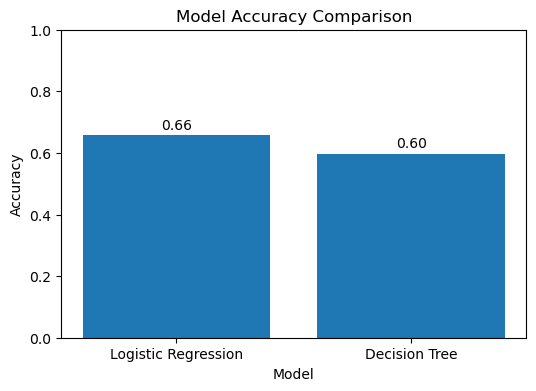

In [15]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree"]
accuracies = [accuracy_lr, accuracy_dt]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center')

plt.show()

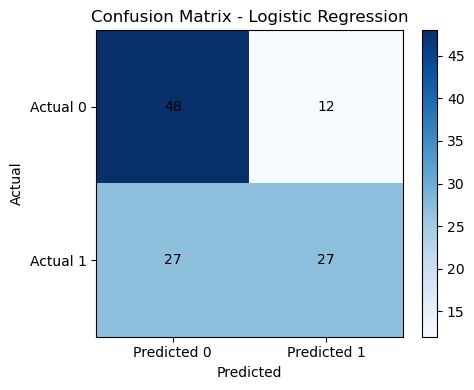

In [16]:
import matplotlib.pyplot as plt
import numpy as np

cm_lr = np.array([
    [48, 12],
    [27, 27]
])

plt.figure(figsize=(5,4))
plt.imshow(cm_lr, cmap="Blues")
plt.colorbar()

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.xticks([0,1], ["Predicted 0", "Predicted 1"])
plt.yticks([0,1], ["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

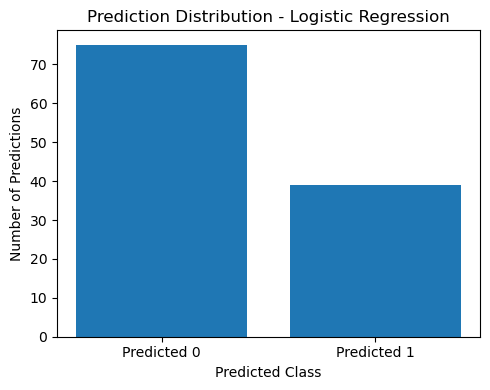

In [19]:
import matplotlib.pyplot as plt

# Spark tarafında sayımları al
pred_counts = (
    pred_lr
    .groupBy("prediction")
    .count()
    .orderBy("prediction")
    .collect()
)

# Python listelerine ayır
labels = [int(row["prediction"]) for row in pred_counts]
counts = [row["count"] for row in pred_counts]

# Bar chart
plt.figure(figsize=(5,4))
plt.bar(labels, counts)
plt.xticks(labels, ["Predicted 0", "Predicted 1"])
plt.xlabel("Predicted Class")
plt.ylabel("Number of Predictions")
plt.title("Prediction Distribution - Logistic Regression")
plt.tight_layout()
plt.show()

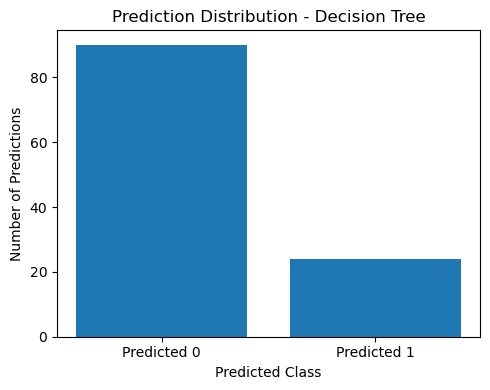

In [20]:
pred_counts_dt = (
    pred_dt
    .groupBy("prediction")
    .count()
    .orderBy("prediction")
    .collect()
)

labels_dt = [int(row["prediction"]) for row in pred_counts_dt]
counts_dt = [row["count"] for row in pred_counts_dt]

plt.figure(figsize=(5,4))
plt.bar(labels_dt, counts_dt)
plt.xticks(labels_dt, ["Predicted 0", "Predicted 1"])
plt.xlabel("Predicted Class")
plt.ylabel("Number of Predictions")
plt.title("Prediction Distribution - Decision Tree")
plt.tight_layout()
plt.show()